## Assignment 3: 
Author: John Courtright\
Instructor: Dr. Zareef Mohammed\
Course: ISAN 5357

This assignment works with 'Cereals-1.csv', a dataset containing nutritional information for various cereal brands.

The variable 'mfr' represents the cereal's manufacturer, where
 
    A = American Home Food Products
    G = General Mills
    K = Kelloggs
    N = Nabisco
    P = Post
    Q = Quaker Oats
    and R = Ralston Purina

The variable 'type' represents if the cereal is served hot or cold, where 'C' is cold and 'H' is hot.


In [1]:
# Necessary Libraries
# import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Question 1

Import the 'cereals-1' dataset, check the data types of the columns. 'name', 'type', and 'mfr' should be objects, the rest are numeric.

In [2]:
df = pd.read_csv('Cereals-1.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     76 non-null     float64
 9   sugars    76 non-null     float64
 10  potass    75 non-null     float64
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(7), int64(6), object(3)
memory usage: 9.8+ KB


## Question 2

Create a scatterplot matrix of the rating, calories, fat, carbs, sugars, fiber, sodium and type. Color the data points based on the type. Each plot should have a black regression (trend) line. The data points should be semi-transparent.

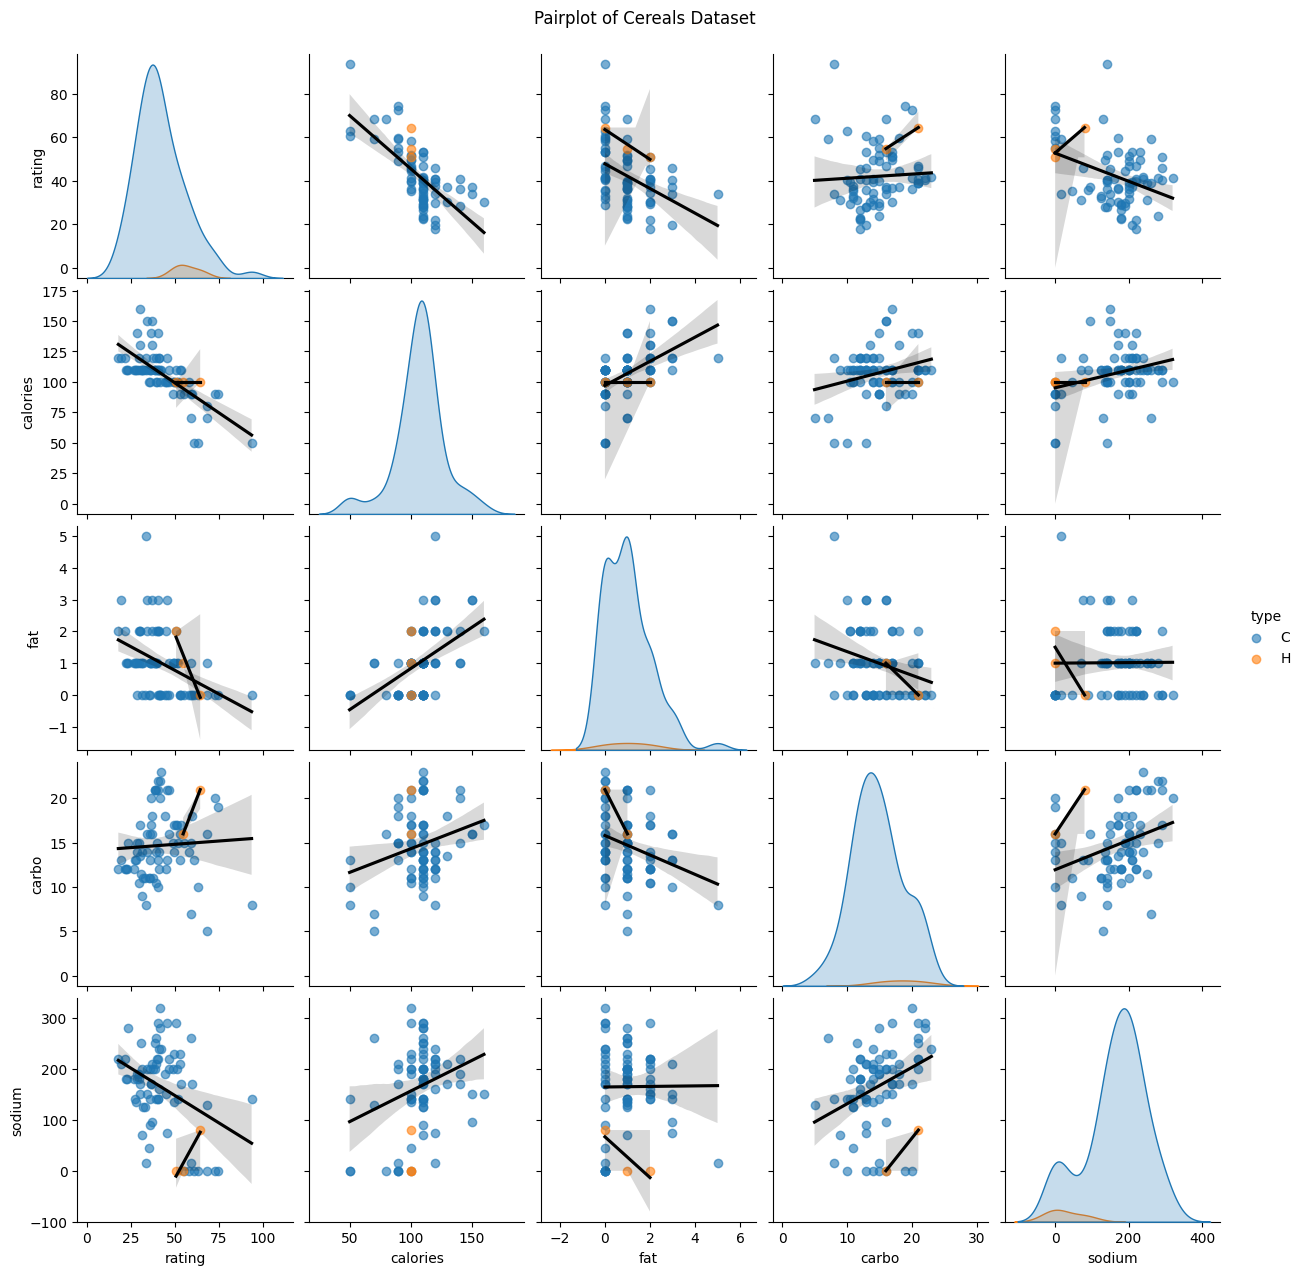

In [3]:
# Pairplot based on rating, calories, fat, carbo, sodium
# Hue by type
sns.pairplot(
    df,
    vars = ['rating', 'calories', 'fat', 'carbo', 'sodium'],
    hue = 'type',
    kind = 'reg',
    plot_kws = {'line_kws':{'color':'black'},
                'scatter_kws': {'alpha':0.6}},
)

plt.suptitle('Pairplot of Cereals Dataset', y = 1.02)
plt.show()

## Question 3 (a)

Create a scatterplot with a trendline (remove the confidence interval shading), of calories (x-axis) and rating (y-axis). The data points should be colored in any color other than the default color, the line should be black, and the axes as well as the title should be bold font, with the title also being size 15.

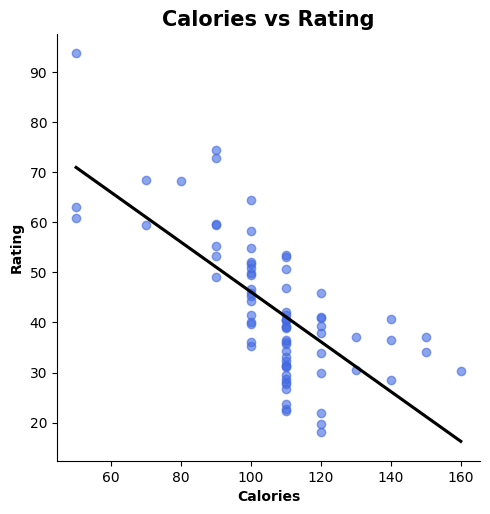

In [4]:
sns.lmplot(
    data = df,
    x = 'calories',
    y = 'rating',
    scatter_kws = {'alpha': 0.6, 'color': 'royalblue'},
    line_kws = {'color': 'black'},
    ci = None
)

plt.title('Calories vs Rating', fontsize = 15, fontweight = 'bold')
plt.xlabel('Calories', fontweight = 'bold')
plt.ylabel('Rating', fontweight = 'bold')
plt.show()

## Question 3 (b)

Do the same as above, but without a trendline, and color the datapoints based on the mfr, while making the shapes different based on the type. Use seaborn to do this -  make sure a legend is produced.

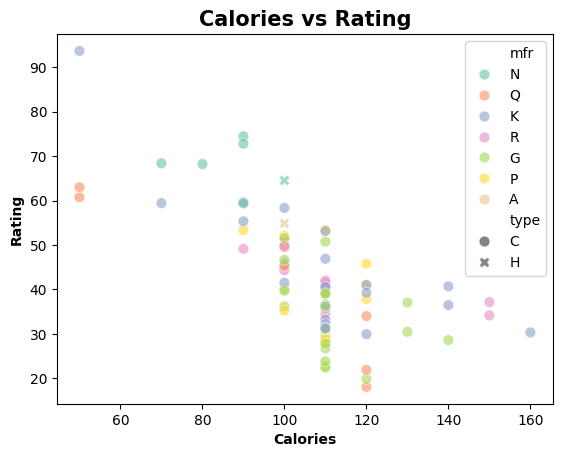

In [5]:
sns.scatterplot(
    data = df,
    x = 'calories',
    y = 'rating',
    hue = 'mfr', # color points by manufacturer
    style = 'type', # different shapes by type
    alpha = 0.6,
    palette = 'Set2',
    s = 60
)

plt.title('Calories vs Rating', fontsize = 15, fontweight = 'bold')
plt.xlabel('Calories', fontweight = 'bold')
plt.ylabel('Rating', fontweight = 'bold')
plt.show()

## Question 3 (c)

Do the same as above, but using pandas - a legend is not needed, and datapoint shapes should be consistent.

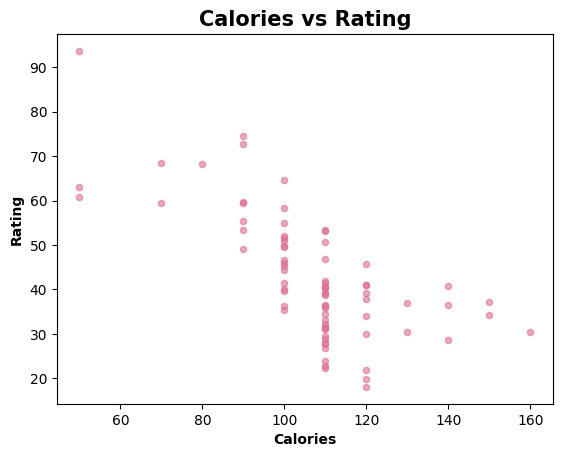

In [6]:
df.plot.scatter(
    x = 'calories',
    y = 'rating',
    alpha = 0.6,
    color = 'palevioletred',
)

plt.title('Calories vs Rating', fontsize = 15, fontweight = 'bold')
plt.xlabel('Calories', fontweight = 'bold')
plt.ylabel('Rating', fontweight = 'bold')
plt.show()

## Question 3 (d)

Do the same as above but use matplotlib - a legend is not needed, and datapoint shapes should be consistent.

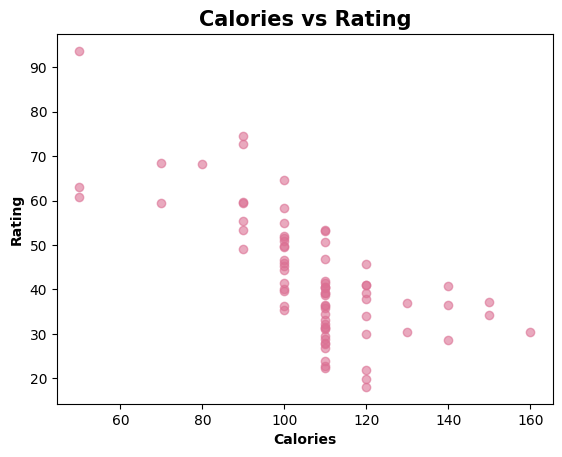

In [7]:
plt.scatter(
    data = df,
    x = 'calories',
    y = 'rating',
    alpha = 0.6,
    color = 'palevioletred'
)

plt.title('Calories vs Rating', fontsize = 15, fontweight = 'bold')
plt.xlabel('Calories', fontweight = 'bold')
plt.ylabel('Rating', fontweight = 'bold')
plt.show()

## Question 4

Create a bar chart showing the average fat, protein, and carbs, and calories per mfr - this should be a side-by-side barchart

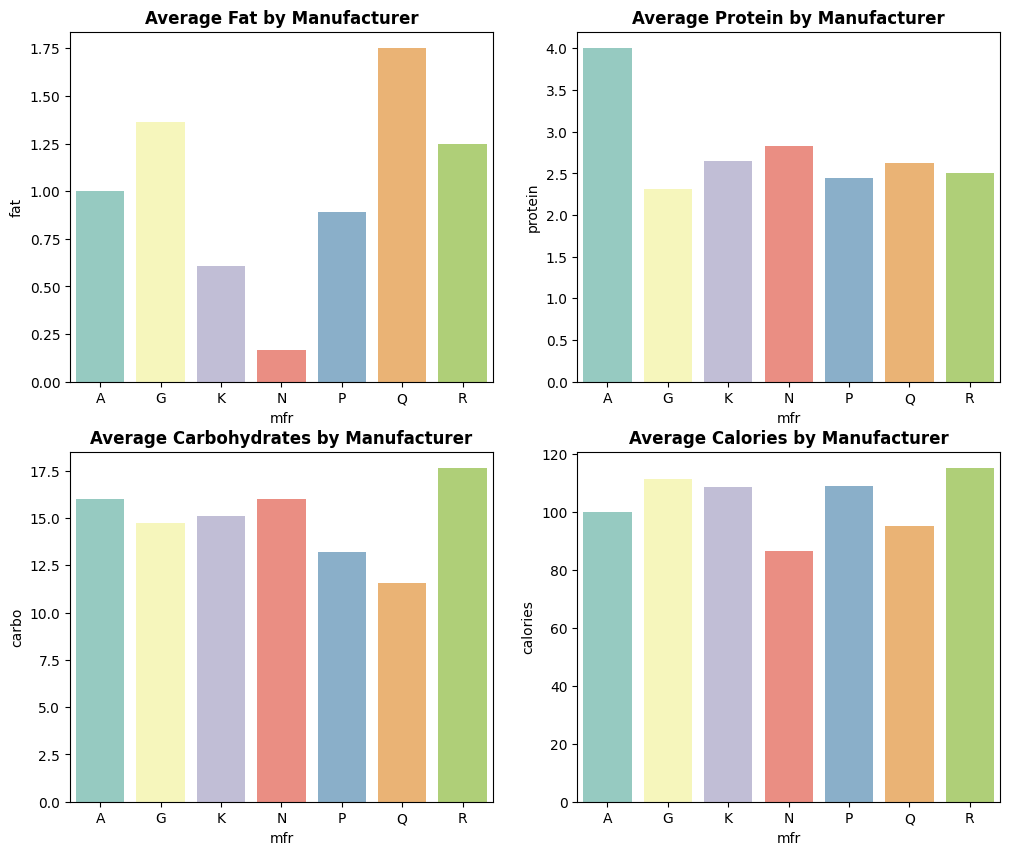

In [ ]:
# Calculate the average value for each nutrient per manufacturer
avg_nutrients = df.groupby('mfr')[['fat', 'protein', 'carbo', 'calories']].mean().reset_index()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.barplot(ax=axes[0, 0], data = avg_nutrients, x = 'mfr', y = 'fat', palette = 'Set3', hue = 'mfr',)
axes[0, 0].set_title('Average Fat by Manufacturer', fontweight = 'bold')

sns.barplot(ax=axes[0, 1], data = avg_nutrients, x = 'mfr', y = 'protein', palette = 'Set3', hue = 'mfr',)
axes[0, 1].set_title('Average Protein by Manufacturer', fontweight = 'bold')

sns.barplot(ax=axes[1, 0], data=avg_nutrients, x = 'mfr', y = 'carbo', palette = 'Set3', hue = 'mfr',)
axes[1, 0].set_title('Average Carbohydrates by Manufacturer', fontweight = 'bold')

sns.barplot(ax=axes[1, 1], data = avg_nutrients, x = 'mfr', y = 'calories', palette = 'Set3', hue = 'mfr',)
axes[1, 1].set_title('Average Calories by Manufacturer', fontweight = 'bold')

plt.show()

## Question 5

Create a density plot of the ratings - customize it as you see fit but it should have some customizations

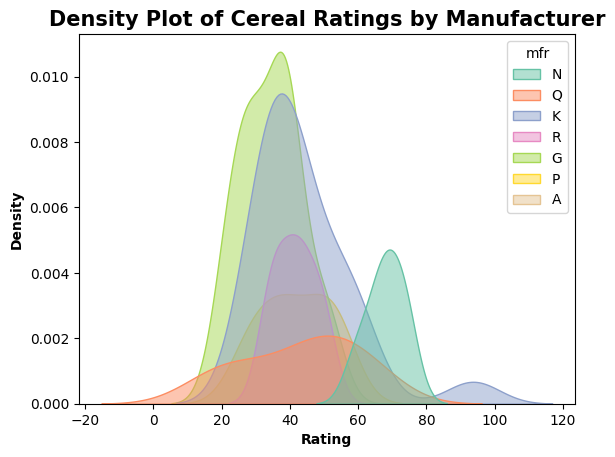

In [16]:
sns.kdeplot(
    data = df,
    x = 'rating',
    hue = 'mfr', # Color by manufacturer
    palette = 'Set2', # Customization
    fill = True,
    alpha = 0.5, # Makes fill transparent for readability
    warn_singular = False # avoids warning
)

plt.title('Density Plot of Cereal Ratings by Manufacturer', fontsize = 15, fontweight = 'bold')
plt.xlabel('Rating', fontweight = 'bold')
plt.ylabel('Density', fontweight = 'bold')
plt.show()

## Question 6

Create histograms for the calories, fat, protein and carbs...customize the color, and bars - they should all be placed in this one area

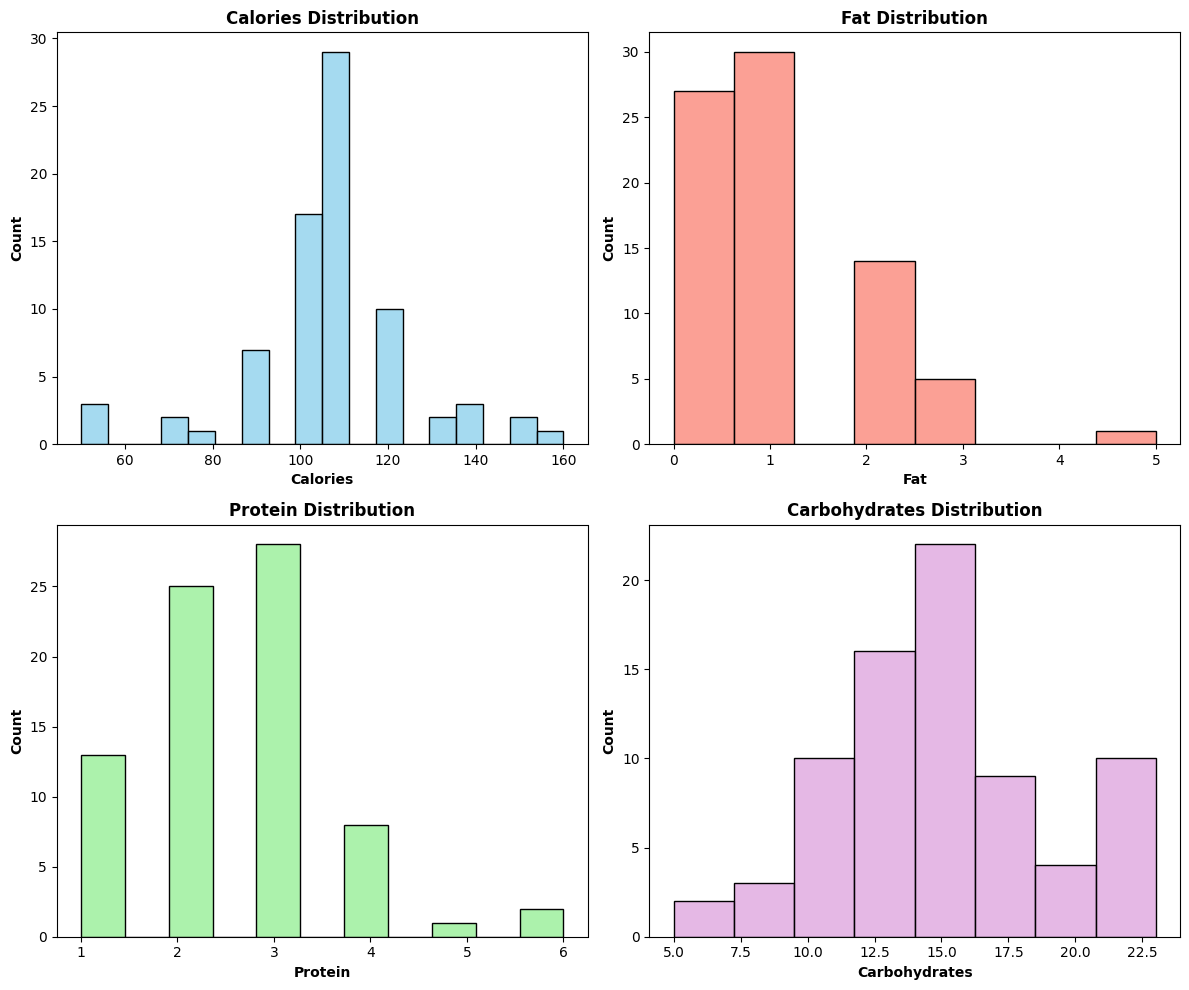

In [20]:
# Histograms for calories, fat, protein, and carbo in a 2x2 subplot

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Calories Histogram
sns.histplot(ax=axes[0, 0], data=df, x='calories', color='skyblue')
axes[0, 0].set_title('Calories Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Calories', fontweight='bold')
axes[0, 0].set_ylabel('Count', fontweight='bold')

# Fat Histogram
sns.histplot(ax=axes[0, 1], data=df, x='fat', color='salmon')
axes[0, 1].set_title('Fat Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Fat', fontweight='bold')
axes[0, 1].set_ylabel('Count', fontweight='bold')

# Protein Histogram
sns.histplot(ax=axes[1, 0], data=df, x='protein', color='lightgreen')
axes[1, 0].set_title('Protein Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Protein', fontweight='bold')
axes[1, 0].set_ylabel('Count', fontweight='bold')

# Carbohydrates Histogram
sns.histplot(ax=axes[1, 1], data=df, x='carbo', color='plum')
axes[1, 1].set_title('Carbohydrates Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Carbohydrates', fontweight='bold')
axes[1, 1].set_ylabel('Count', fontweight='bold')

plt.tight_layout()
plt.show()

## Question 7

Create a boxplot of the rating per mfr - customize the color, etc....basically...don't make it "basic".

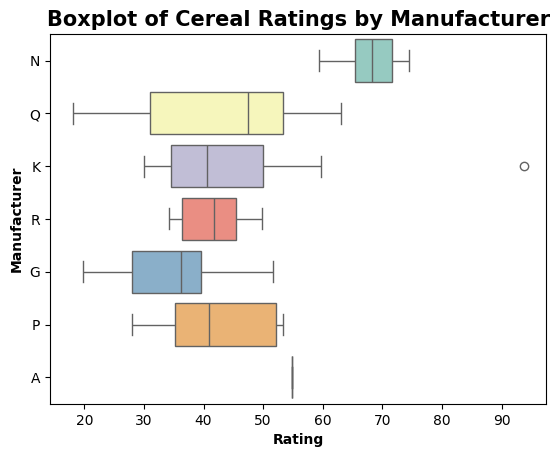

In [22]:
sns.boxplot(
    data = df,
    x = 'rating',
    y = 'mfr',
    hue = 'mfr',
    palette = 'Set3'
)

plt.title('Boxplot of Cereal Ratings by Manufacturer', fontsize = 15, fontweight = 'bold')
plt.xlabel('Rating', fontweight = 'bold')
plt.ylabel('Manufacturer', fontweight = 'bold')
plt.show()

## Question 8

Create a heatmap with the correlations of the numerical variables in question 2: rating, calories, fat, carbs, sugars, fiber, sodium

<Axes: >

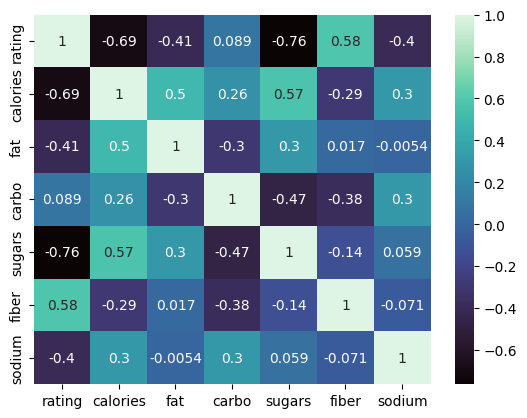

In [31]:
# Create new df with rating, calories, fat, carbo, sugars, fiber, and sodium
df2 = df[['rating', 'calories', 'fat', 'carbo', 'sugars', 'fiber', 'sodium']]

# Create heatmap
sns.heatmap(data = df2.corr(), annot = True, cmap = 'mako')

## Question 9

Filter the data where the only mfrs are American Home Food Products, Kelloggs, Nabisco, Post, and Ralston Purina.
Create a bar chart of the ratings per type.

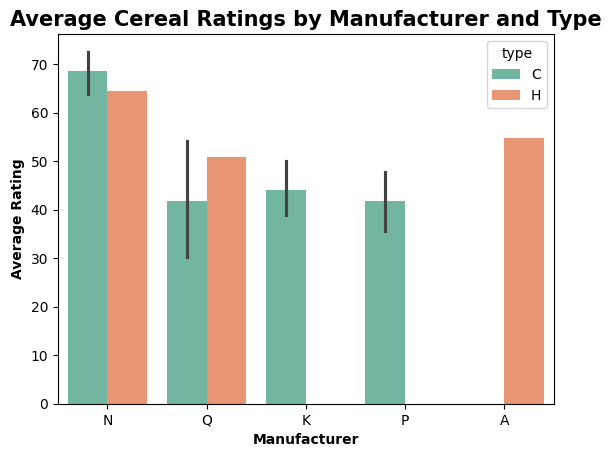

In [34]:
# Filter df to include rows where mfrs is American Home Food Products (A),
    # Kellogg's (K), Nabisco (N), Post (P), and Ralston Purina (Q)

df3 = df[df['mfr'].isin(['A', 'K', 'N', 'P', 'Q'])]
# df3.head()

# Create bar chart of ratings per type
sns.barplot(
    data = df3,
    x = 'mfr',
    y = 'rating',
    hue = 'type',
    palette = 'Set2'
)

plt.title('Average Cereal Ratings by Manufacturer and Type', fontsize = 15, fontweight = 'bold')
plt.xlabel('Manufacturer', fontweight = 'bold')
plt.ylabel('Average Rating', fontweight = 'bold')
plt.show()

## Question 10

Filter the data (not the including the filtering from question 9), where ratings are above 30. Create any diagram you would like, based on this new data that you filtered. 

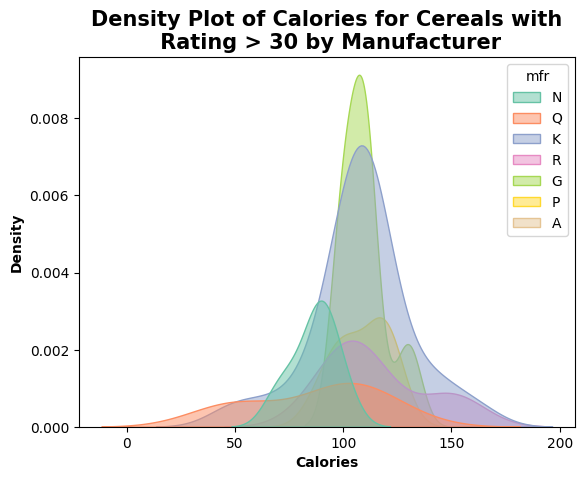

In [39]:
# Filter the df to include only rows where rating is greater than 30
df4 = df[df['rating'] > 30]
# df4.head()

# Create a density plot of calories for cereals with rating greater than 30
sns.kdeplot(
    data = df4,
    x = 'calories',
    hue = 'mfr', # Color by manufacturer
    palette = 'Set2', # Customization
    fill = True,
    alpha = 0.5, # Makes fill transparent for readability
    warn_singular = False # avoids warning
)

plt.title('Density Plot of Calories for Cereals with\n Rating > 30 by Manufacturer', fontsize = 15, fontweight = 'bold', )
plt.xlabel('Calories', fontweight = 'bold')
plt.ylabel('Density', fontweight = 'bold')
plt.show()